In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\Ali\Downloads\Iris_data\Iris.csv")

In [4]:
print(df.head())
print(df.shape)

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
(150, 6)


In [5]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [8]:
X = df.drop(columns = ["Id", "Species"])
y = df["Species"]

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)


In [10]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [11]:
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state =42)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
df_binary = df[df["Species"] != "Iris-virginica"]

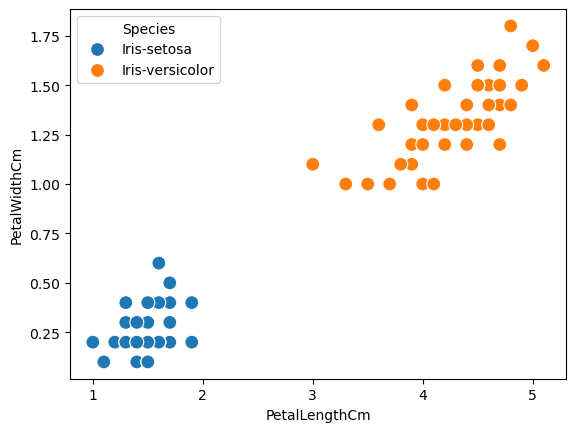

In [16]:
import seaborn as sns
sns.scatterplot(
    data=df_binary,
    x='PetalLengthCm',
    y='PetalWidthCm',
    hue='Species',
    s=100
)

plt.show()

In [17]:
y = df_binary['Species'].map({'Iris-setosa': 0, 'Iris-versicolor':1})

In [18]:
y

0     0
1     0
2     0
3     0
4     0
     ..
95    1
96    1
97    1
98    1
99    1
Name: Species, Length: 100, dtype: int64

In [19]:
df_binary['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Name: count, dtype: int64

In [23]:
def step(z):
    return 1 if z >= 0 else 0

In [28]:
X_binary = df_binary.drop(columns=["Id", "Species"])
y_binary = df_binary["Species"].map({"Iris-setosa": 0, "Iris-versicolor": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X_binary.values,
    y_binary.values,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


def perceptron(X, y, learning_rate=0.1, epochs=1000):
    X_bias = np.insert(X, 0, 1, axis=1)
    weights = np.zeros(X_bias.shape[1])

    for _ in range(epochs):
        for x, target in zip(X_bias, y):
            prediction = step(np.dot(x, weights))
            if prediction != target:
                weights += learning_rate * (target - prediction) * x

    return weights[0], weights[1:]

bias, coef = perceptron(X_train, y_train)

predictions = []
for sample in X_test:
    sample_with_bias = np.insert(sample, 0, 1)
    predictions.append(step(np.dot(sample_with_bias, np.array([bias, *coef]))))

predictions = np.array(predictions)
accuracy = np.mean(predictions == y_test)

print("Bias:", bias)
print("Weights:", coef)
print("Accuracy:", accuracy)

Bias: -0.1
Weights: [ 0.05796033 -0.23365314  0.21520931  0.21350979]
Accuracy: 1.0


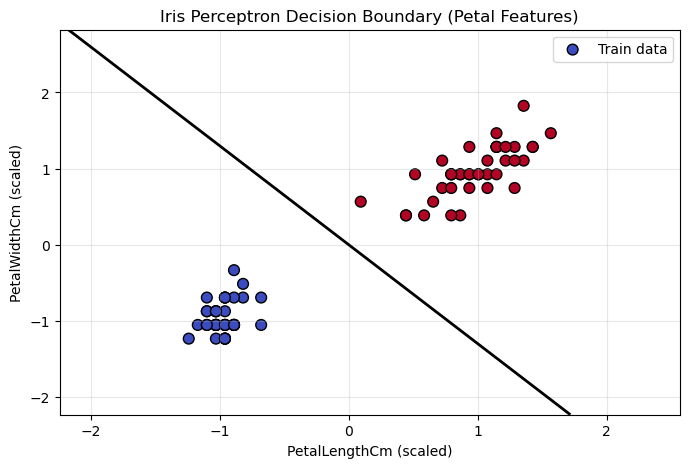

In [29]:
plot_X = df_binary[["PetalLengthCm", "PetalWidthCm"]].values
plot_y = df_binary["Species"].map({"Iris-setosa": 0, "Iris-versicolor": 1}).values

plot_X_train, plot_X_test, plot_y_train, plot_y_test = train_test_split(
    plot_X,
    plot_y,
    test_size=0.2,
    random_state=42,
    stratify=plot_y
)

plot_scaler = StandardScaler()
plot_X_train = plot_scaler.fit_transform(plot_X_train)
plot_X_test = plot_scaler.transform(plot_X_test)

plot_bias, plot_coef = perceptron(plot_X_train, plot_y_train)

x_min, x_max = plot_X_train[:, 0].min() - 1, plot_X_train[:, 0].max() + 1
y_min, y_max = plot_X_train[:, 1].min() - 1, plot_X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

boundary = plot_bias + plot_coef[0] * xx + plot_coef[1] * yy

plt.figure(figsize=(8, 5))
plt.scatter(plot_X_train[:, 0], plot_X_train[:, 1], c=plot_y_train, cmap='coolwarm', edgecolor='k', s=60, label='Train data')
plt.contour(xx, yy, boundary, levels=[0], colors='black', linewidths=2)
plt.title('Iris Perceptron Decision Boundary (Petal Features)')
plt.xlabel('PetalLengthCm (scaled)')
plt.ylabel('PetalWidthCm (scaled)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()